# Librerias

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as sklearn_train_test_split

import os
import tarfile
import time

#Para garantizar reproducibilidad en resultados
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

path_taller = "/content/drive/MyDrive/Maestria Andes/Sistemas_recomendacion__/Sistemas_recomendacion/Taller 2"
FIGS_FOLDER = '../docs/figs/'

# Configuración global
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option('display.float_format', '{:.3f}'.format) # Configuración global de presentación de .3 decimales en resul

# Carga de datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Extracción de datos de .tar
tar_path = path_taller+"/yelp_dataset.tar"

# Carpeta de extracción
extract_path = "/content/yelp_dataset"
os.makedirs(extract_path, exist_ok=True)

max_retries = 3
retry_delay_seconds = 5

for attempt in range(max_retries):
    try:
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(path=extract_path)
        print(f"Files extracted to: {extract_path}")
        break # Exit loop if extraction is successful
    except OSError as e:
        if "Transport endpoint is not connected" in str(e) and attempt < max_retries - 1:
            print(f"Attempt {attempt + 1} failed: {e}. Retrying in {retry_delay_seconds} seconds...")
            time.sleep(retry_delay_seconds)
        else:
            # Re-raise the exception if max retries reached or it's a different OSError
            print(f"Failed to extract files after {attempt + 1} attempts.")
            raise


/tmp/ipykernel_26151/29049584.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Files extracted to: /content/yelp_dataset


### **`df_review`**: Almacena las calificaciones que los usuarios han dado a los negocios.

In [4]:
df_review = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_review.json', lines=True)
print(df_review.shape)
print("Numero de usuarios unicos:", df_review['user_id'].nunique())
print("Numero de negocios unicos:", df_review['business_id'].nunique())
display(df_review.info())
display(df_review)

(6990280, 9)
Numero de usuarios unicos: 1987929
Numero de negocios unicos: 150346
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990280 entries, 0 to 6990279
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   review_id    object        
 1   user_id      object        
 2   business_id  object        
 3   stars        int64         
 4   useful       int64         
 5   funny        int64         
 6   cool         int64         
 7   text         object        
 8   date         datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 480.0+ MB


None

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
...,...,...,...,...,...,...,...,...,...
6990275,H0RIamZu0B0Ei0P4aeh3sQ,qskILQ3k0I_qcCMI-k6_QQ,jals67o91gcrD4DC81Vk6w,5,1,2,1,Latest addition to services from ICCU is Apple...,2014-12-17 21:45:20
6990276,shTPgbgdwTHSuU67mGCmZQ,Zo0th2m8Ez4gLSbHftiQvg,2vLksaMmSEcGbjI5gywpZA,5,2,1,2,"This spot offers a great, affordable east week...",2021-03-31 16:55:10
6990277,YNfNhgZlaaCO5Q_YJR4rEw,mm6E4FbCMwJmb7kPDZ5v2Q,R1khUUxidqfaJmcpmGd4aw,4,1,0,0,This Home Depot won me over when I needed to g...,2019-12-30 03:56:30
6990278,i-I4ZOhoX70Nw5H0FwrQUA,YwAMC-jvZ1fvEUum6QkEkw,Rr9kKArrMhSLVE9a53q-aA,5,1,0,0,For when I'm feeling like ignoring my calorie-...,2022-01-19 18:59:27


In [ ]:
print(f"El archivo review.json contiene {df_review.shape[0]} calificaciones (Reviews) realizadas por {df_review['user_id'].nunique()} usuarios acerca de {df_review['business_id'].nunique()} ítems (películas). ")

El archivo review.json contiene 6990280 calificaciones (Reviews) realizadas por 1987929 usuarios acerca de 150346 ítems (películas). 


### **`df_business`**: Contiene información de cada negocio.

In [5]:
df_business = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_business.json', lines=True)
print("Numero de negocios:", df_business['business_id'].nunique())
display(df_business.info())
display(df_business)

Numero de negocios: 150346
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB


None

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.427,-119.711,5.000,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551,-90.336,3.000,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223,-110.880,3.500,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.956,-75.156,4.000,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338,-75.472,4.500,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468,-113.492,3.000,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115,-86.767,4.000,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.909,-86.065,3.500,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782,-89.951,4.000,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [ ]:
print(f"El archivo business.json contiene la información referente a los {df_business.shape[0]} negocios tales como nombre, dirección y atributos.")

El archivo business.json contiene la información referente a los 150346 negocios tales como nombre, dirección y atributos.


#### categorias

In [ ]:
# Creamos un set vacio para almacenar los generos unicos
all_genres = set()
# Iteramos sobre la columna 'genres' del DataFrame de peliculas
for genres in df_business['categories']:
  # Dividimos la cadena de generos por el caracter '|' y actualizamos el set
  all_genres.update(genres.split('|'))
# Eliminamos el genero '(no genres listed)' del set de generos unicos
all_genres.discard('(no genres listed)')
print(f"{len(all_genres)} Generos unicos: {sorted(all_genres)}")

# Para cada genero unico, creamos una nueva columna en el DataFrame de peliculas que indica con un 1 si la pelicula pertenece a ese genero y con un 0 si no pertenece
for genre in all_genres:
  df_business[genre] = df_business['genres'].apply(lambda x: 1 if genre in x else 0)
# Eliminamos la columna original de generos ya que ahora tenemos columnas binarias para cada genero
df_business = df_business.drop('genres', axis=1, errors='ignore')


19 Generos unicos: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


#### calificación promedio de la pelicula

In [ ]:
# Calculamos el rating promedio para cada pelicula agrupando por 'movieId' y calculando la media de la columna 'rating'
average_ratings = df_review.groupby("business_id")["stars"].mean().reset_index()
average_ratings

,business_id,stars
0,---kPU91CF4Lq2-WlRu9Lw,4.500000
1,--0iUa4sNDFiZFrAdIWhZQ,3.214286
2,--30_8IhuyMHbSOcNWd6DQ,3.555556
3,--7PUidqRWpRSpXebiyxTg,1.750000
4,--7jw19RH9JKXgFohspgQw,4.230769
...,...,...
150341,zznZqH9CiAznbkV6fXyHWA,4.916667
150342,zztOG2cKm87I6Iw_tleZsQ,4.833333
150343,zzu6_r3DxBJuXcjnOYVdTw,3.625000
150344,zzw66H6hVjXQEt0Js3Mo4A,3.600000


In [ ]:
def average_rating_weighted_by_user_activity(df_ratings, df_movies):
    """Calcula el promedio bayesiano de las calificaciones de las películas,
    ponderado por la actividad de los usuarios."""
    items_stats = df_ratings.groupby('movieId')['rating'].agg({'count','mean','var'}).reset_index()

    # 1. Calcular C (el promedio global de todas las calificaciones)
    C = items_stats['mean'].mean()

    # 2. Calcular m (el mínimo de votos requeridos).
    # Aquí usamos el percentil 90: la película debe tener más votos que el 90% de la base de datos
    m = items_stats['count'].quantile(0.90)

    print(f"Promedio global ratings (C): {C:.2f}")
    print(f"Cantidad de ratings mínimos (m) - Percentil 90: {m}")


    # 3. Definir la función del Promedio Bayesiano
    def weighted_rating(x, m=m, C=C):
        v = x['count']
        R = x['mean']
        # Fórmula
        return (v/(v+m) * R) + (m/(m+v) * C)

    items_stats['score_bayesiano'] = items_stats.apply(weighted_rating, axis=1)
    return items_stats[['score_bayesiano', 'movieId']].merge(df_movies, on='movieId', how='left')

In [ ]:
df_movies = average_rating_weighted_by_user_activity(df_ratings, df_movies)
df_movies

Promedio global ratings (C): 3.13
Cantidad de ratings mínimos (m) - Percentil 90: 1305.7000000000007


,score_bayesiano,movieId,title,Thriller,Comedy,Crime,Horror,Fantasy,Children,IMAX,...,Animation,Western,Documentary,Drama,Film-Noir,Sci-Fi,Action,Musical,Adventure,year
0,3.901064,1,Toy Story (1995),0,1,0,0,1,1,0,...,1,0,0,0,0,0,0,0,1,1995
1,3.207609,2,Jumanji (1995),0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,1995
2,3.149381,3,Grumpier Old Men (1995),0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1995
3,2.948770,4,Waiting to Exhale (1995),0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1995
4,3.071244,5,Father of the Bride Part II (1995),0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26739,3.133863,131254,Kein Bund für's Leben (2007),0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2007
26740,3.133863,131256,"Feuer, Eis & Dosenbier (2002)",0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2002
26741,3.132715,131258,The Pirates (2014),0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2014
26742,3.133098,131260,Rentun Ruusu (2001),0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2001


Para el modelo colaborativo necesitamos conservar solo las peliculas que tengan ratings. Adicionalmente, por experiencia de usuario solo vamos a conservar las peliculas de las cuales conozcamos su titulo (ya que no podemos recomendar un id). Por lo que hacemos un merge entre `df_movies` y `df_ratings` de tipo `inner` de modo que solo conservamos los id de peliculas que esten en ambos datasets.

In [ ]:
df_movies = df_movies.merge(average_ratings,on="movieId", how="inner").rename(columns={"rating": "average_rating"})

Revisamos que no hayan duplicados

In [ ]:
df_movies.duplicated().sum()

Verificamos que todas las peliculas tengan ratings

In [ ]:
df_movies.average_rating.isna().sum()

Revisamos número de peliculas unicas


In [ ]:
df_movies["movieId"].nunique()


Extraemos la lista final de peliculas validas


In [ ]:
movies_ids_with_ratings_and_titles = set(df_movies['movieId'].unique())

df_ratings = df_ratings[df_ratings['movieId'].isin(movies_ids_with_ratings_and_titles)]
df_ratings.rating.isna().sum()

Revisamos la nueva estructura de `df_movies`

In [ ]:
order = ['movieId', 'title', 'year', 'average_rating', "score_bayesiano", 'Adventure', 'Sci-Fi', 'Musical', 'Drama',
       'Romance', 'Mystery', 'Western', 'IMAX', 'Thriller', 'Film-Noir',
       'Children', 'War', 'Comedy', 'Horror', 'Crime', 'Animation', 'Fantasy',
       'Documentary', 'Action']
df_movies = df_movies[order]

In [ ]:
df_movies.info()
display(df_movies.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26744 entries, 0 to 26743
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movieId          26744 non-null  int64  
 1   title            26744 non-null  object 
 2   year             26722 non-null  Int64  
 3   average_rating   26744 non-null  float64
 4   score_bayesiano  26744 non-null  float64
 5   Adventure        26744 non-null  int64  
 6   Sci-Fi           26744 non-null  int64  
 7   Musical          26744 non-null  int64  
 8   Drama            26744 non-null  int64  
 9   Romance          26744 non-null  int64  
 10  Mystery          26744 non-null  int64  
 11  Western          26744 non-null  int64  
 12  IMAX             26744 non-null  int64  
 13  Thriller         26744 non-null  int64  
 14  Film-Noir        26744 non-null  int64  
 15  Children         26744 non-null  int64  
 16  War              26744 non-null  int64  
 17  Comedy      

,movieId,title,year,average_rating,score_bayesiano,Adventure,Sci-Fi,Musical,Drama,Romance,...,Film-Noir,Children,War,Comedy,Horror,Crime,Animation,Fantasy,Documentary,Action
0,1,Toy Story (1995),1995,3.921240,3.901064,1,0,0,0,0,...,0,1,0,1,0,0,1,1,0,0
1,2,Jumanji (1995),1995,3.211977,3.207609,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2,3,Grumpier Old Men (1995),1995,3.151040,3.149381,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,4,Waiting to Exhale (1995),1995,2.861393,2.948770,0,0,0,1,1,...,0,0,0,1,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),1995,3.064592,3.071244,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_movies.to_csv('../data/produccion/movie.csv', index=False)
df_ratings.to_csv('../data/produccion/rating.csv', index=False)

In [ ]:
print("Numero de usuarios unicos:", df_ratings['userId'].nunique())
print("Numero de peliculas unicas:", df_ratings['movieId'].nunique())
print("Numero de calificaciones:", df_ratings['rating'].shape[0])

Numero de usuarios unicos: 138493
Numero de peliculas unicas: 26744
Numero de calificaciones: 20000263


# **Exploración de Datos**

## Distribución de ratings

In [ ]:
conteo = df_review['stars'].value_counts().sort_index()
conteo

,count
stars,
1,1069561
2,544240
3,691934
4,1452918
5,3231627


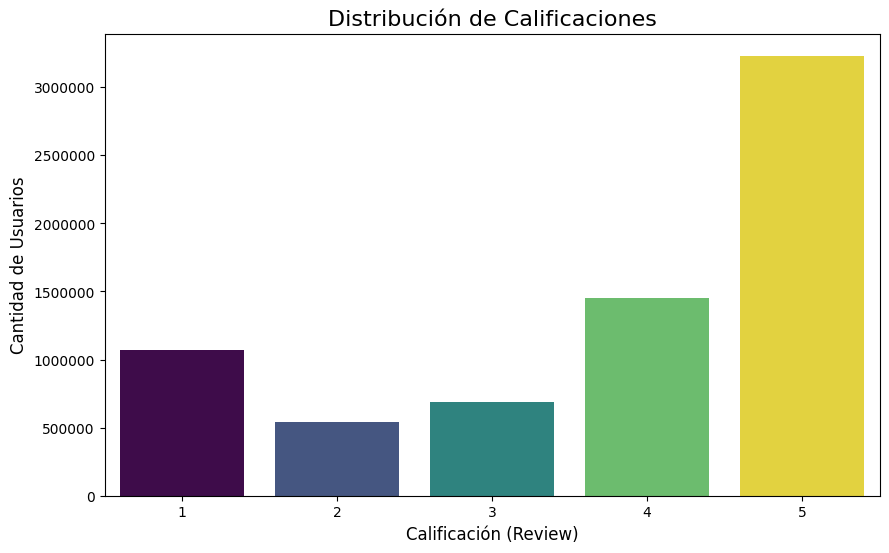

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Creamos el gráfico directamente desde el DataFrame
sns.countplot(data=df_review, x='stars', hue='stars', palette='viridis', legend=False)

# Añadir títulos y formato
plt.title('Distribución de Calificaciones', fontsize=16)
plt.xlabel('Calificación (Review)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

# Formatear el eje Y para que no muestre notación científica (ej. 1e6)
plt.ticklabel_format(style='plain', axis='y')

# Carpeta de extracción
os.makedirs(path_taller+'/Images', exist_ok=True)
plt.savefig(path_taller+'/Images/dist_reviews.png')
plt.show()

In [9]:
df_review['stars'].describe()

,stars
count,6.990280e+06
mean,3.748584e+00
std,1.478705e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,5.000000e+00
max,5.000000e+00


La distribución de las calificaciones (ratings) se presenta en la Figura 1.  La variable rating es una variable que toma valores discretos entre 0.5 y 5.0, con pasos de 0.5. Se observa una concentración en calificaciones altas de las escala. La calificación más frecuente es 4.0 y la mediana es 3.5. Solo el 25% de las calificaciones son 3 o menos. El 50% de las calificaciones se encuentra entre 3 y 4. El 25% restante es 4 o mas.  

## ¿Cómo es la distribución del número de ratings por usuario?



In [22]:
user_stats =df_review.groupby('user_id')['stars'].agg({'count','mean','std'}).sort_values(by='count', ascending=False)
user_stats

,mean,std,count
user_id,,,
_BcWyKQL16ndpBdggh2kNA,3.638,0.914,3048
Xw7ZjaGfr0WNVt6s_5KZfA,4.073,0.845,1840
0Igx-a1wAstiBDerGxXk2A,3.990,0.682,1747
-G7Zkl1wIWBBmD0KRy_sCw,3.653,0.932,1682
ET8n-r7glWYqZhuR6GcdNw,4.047,0.916,1653
...,...,...,...
zzzMBVS73g3ZJ7qL8JyhiA,1.000,NaN,1
zzzGgfvrSJ4AQeKtcgocIw,3.000,NaN,1
zzzCg-_lpyYE82TlJCdwdw,5.000,NaN,1


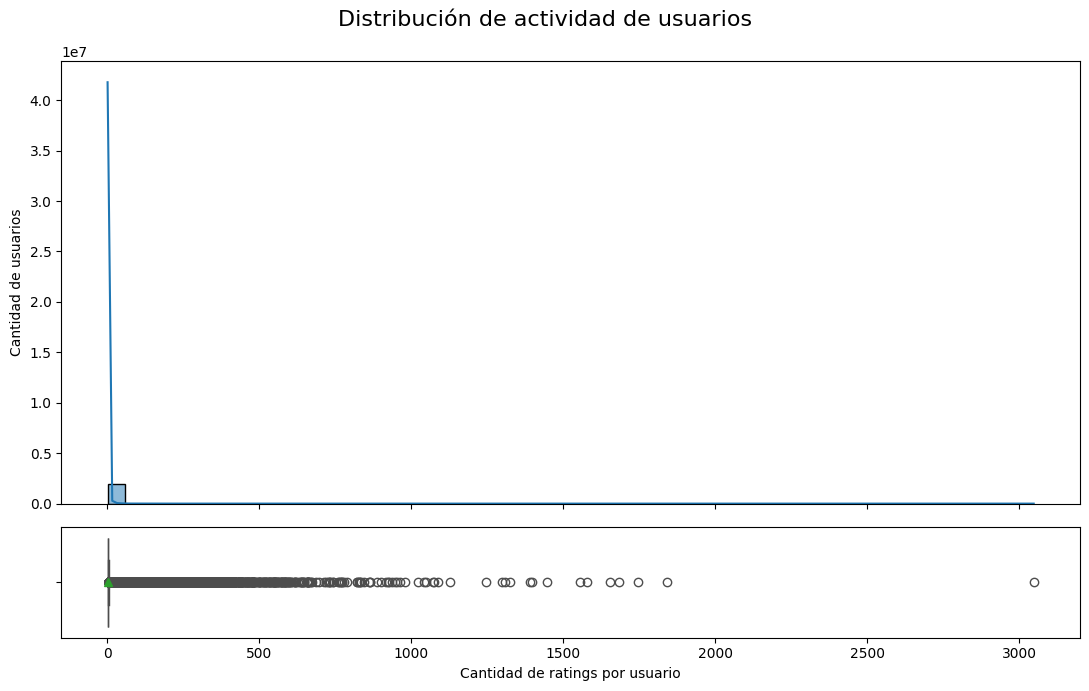

,count
count,1987929.000
mean,3.516
std,12.771
min,1.000
25%,1.000
50%,1.000
75%,3.000
max,3048.000


In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=user_stats,
    x='count',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=user_stats,
    x='count',
    ax=ax2,
    color='orange',
    showmeans = True,
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución de actividad de usuarios', fontsize=16)
plt.xlabel('Cantidad de ratings por usuario')
plt.ylabel('')
plt.tight_layout()
plt.savefig(path_taller + '/Images/usuarios_actividad.png')
plt.show()
user_stats['count'].describe()

In [23]:
user_stats['count'].describe(percentiles=[.5,.65,.75,.80,.85,.90,.95])

,count
count,1987929.000
mean,3.516
std,12.771
min,1.000
50%,1.000
65%,2.000
75%,3.000
80%,3.000
85%,4.000
90%,6.000


Al analizar la actividad de los usuarios (figura 2) se observa que el número de ratings por usuario presenta una distribución fuertemente asimétrica positiva (right-skewed) y de cola larga (long-tail distribution). Lo anterior nos indica que la mayoría de los usuarios califica pocas películas, mientras que unos pocos califican muchísimas. En promedio los usuarios realizan 144 calificaciones, sin embargo, la mayoría de los usuarios están muy por debajo del promedio (la mediana es de 68 calificaciones). Un usuario en el dataset califica entre 20 y 9254 peliculas. El 25% de los usuarios califica 35 peliculas o menos. El 50% califica entre 35 y 155 peliculas. Solo el 25% de los usuarios supera 155 ratings.

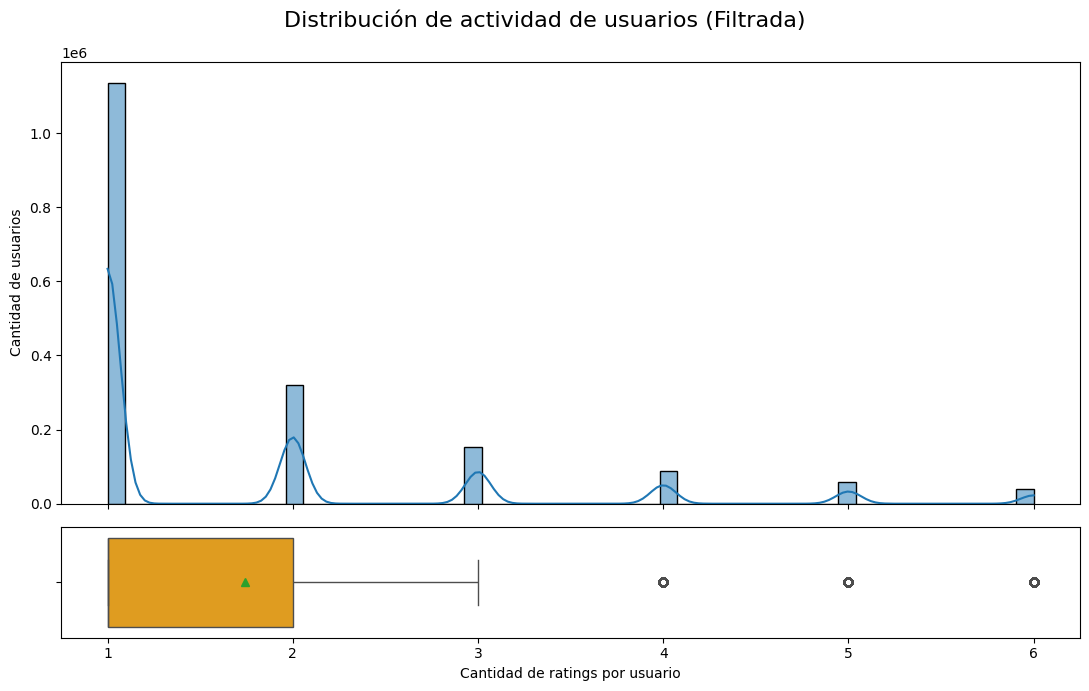

,count
count,1800161.000
mean,1.742
std,1.226
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,6.000


In [18]:
# eliminar outliers
Q1 = user_stats['count'].quantile(0.25)
Q3 = user_stats['count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_user_stats = user_stats[(user_stats['count'] >= lower_bound) & (user_stats['count'] <= upper_bound)]

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=filtered_user_stats,
    x='count',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=filtered_user_stats,
    x='count',
    ax=ax2,
    color='orange',
    showmeans = True,
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución de actividad de usuarios (Filtrada)', fontsize=16)
plt.xlabel('Cantidad de ratings por usuario')
plt.ylabel('')
plt.tight_layout()
plt.show()
filtered_user_stats['count'].describe()

## ¿Cómo es la distribución del promedio de calificación por usuario?

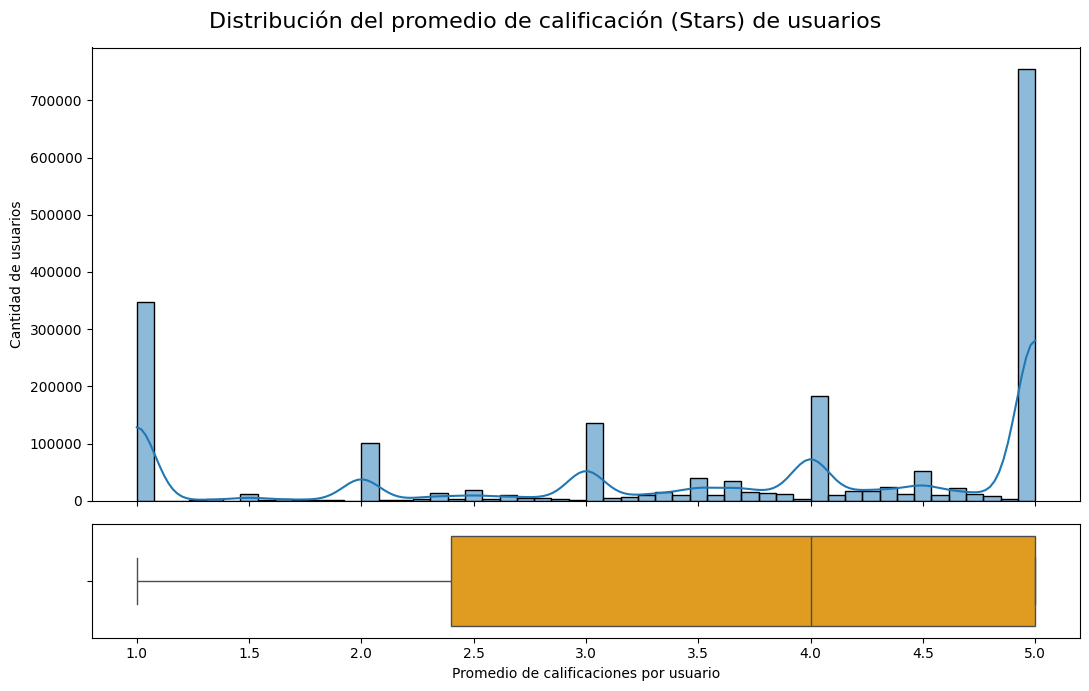

,mean
count,1987929.000
mean,3.605
std,1.507
min,1.000
25%,2.400
50%,4.000
75%,5.000
max,5.000


In [21]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=user_stats,
    x='mean',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=user_stats,
    x='mean',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del promedio de calificación (Stars) de usuarios', fontsize=16)
plt.xlabel('Promedio de calificaciones por usuario')
plt.ylabel('')
plt.tight_layout()
plt.savefig(path_taller + '/Images/usuarios_promedio.png')
plt.show()
user_stats['mean'].describe()


La distribución del promedio de calificaciones tiene forma de campana y la media (3.63) es muy parecida a la mediana (3.65), por lo que podriamos decir que la distribución del promedio de rating por usuario es aproximadamente normal (gaussiana).

La distribución del promedio de calificaciones por usuario se concentra alrededor de valores entre 3 y 4, lo que indica un sesgo positivo en el uso de la escala de rating por parte de los usuarios.

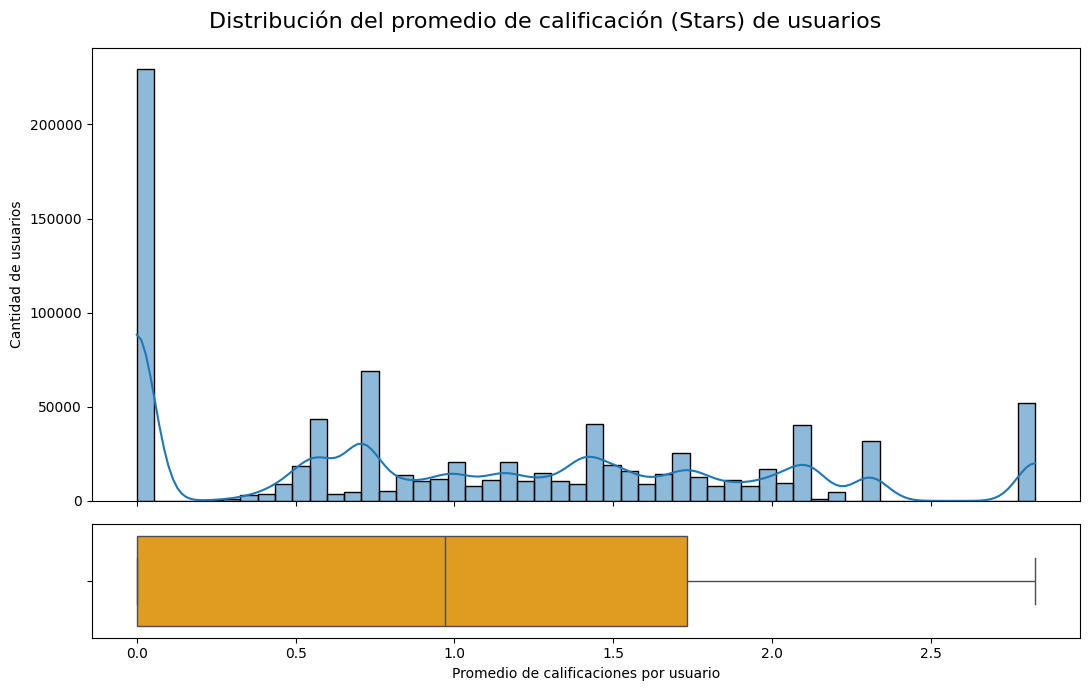

,std
count,851921.000
mean,1.047
std,0.866
min,0.000
25%,0.000
50%,0.972
75%,1.732
max,2.828


In [27]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=user_stats[user_stats['count']>1],
    x='std',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de usuarios')


# Boxplot
sns.boxplot(
    data=user_stats,
    x='std',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del promedio de calificación (Stars) de usuarios', fontsize=16)
plt.xlabel('Promedio de calificaciones por usuario')
plt.ylabel('')
plt.tight_layout()
plt.show()
user_stats[user_stats['count']>1]['std'].describe()


## Estadisticas de los items

In [9]:
items_stats = df_review.groupby('business_id')['stars'].agg({'count','mean','std'}).reset_index().join(df_business['name'], how='left')
items_stats

,business_id,std,count,mean,name
0,---kPU91CF4Lq2-WlRu9Lw,0.978,24,4.500,"Abby Rappoport, LAC, CMQ"
1,--0iUa4sNDFiZFrAdIWhZQ,1.369,14,3.214,The UPS Store
2,--30_8IhuyMHbSOcNWd6DQ,1.944,9,3.556,Target
3,--7PUidqRWpRSpXebiyxTg,1.055,12,1.750,St Honore Pastries
4,--7jw19RH9JKXgFohspgQw,1.536,13,4.231,Perkiomen Valley Brewery
...,...,...,...,...,...
150341,zznZqH9CiAznbkV6fXyHWA,0.289,12,4.917,Binh's Nails
150342,zztOG2cKm87I6Iw_tleZsQ,0.408,6,4.833,Wild Birds Unlimited
150343,zzu6_r3DxBJuXcjnOYVdTw,0.916,8,3.625,Claire's Boutique
150344,zzw66H6hVjXQEt0Js3Mo4A,1.949,5,3.600,Cyclery & Fitness Center


### Distribución del número de calificaciones (rating) por película

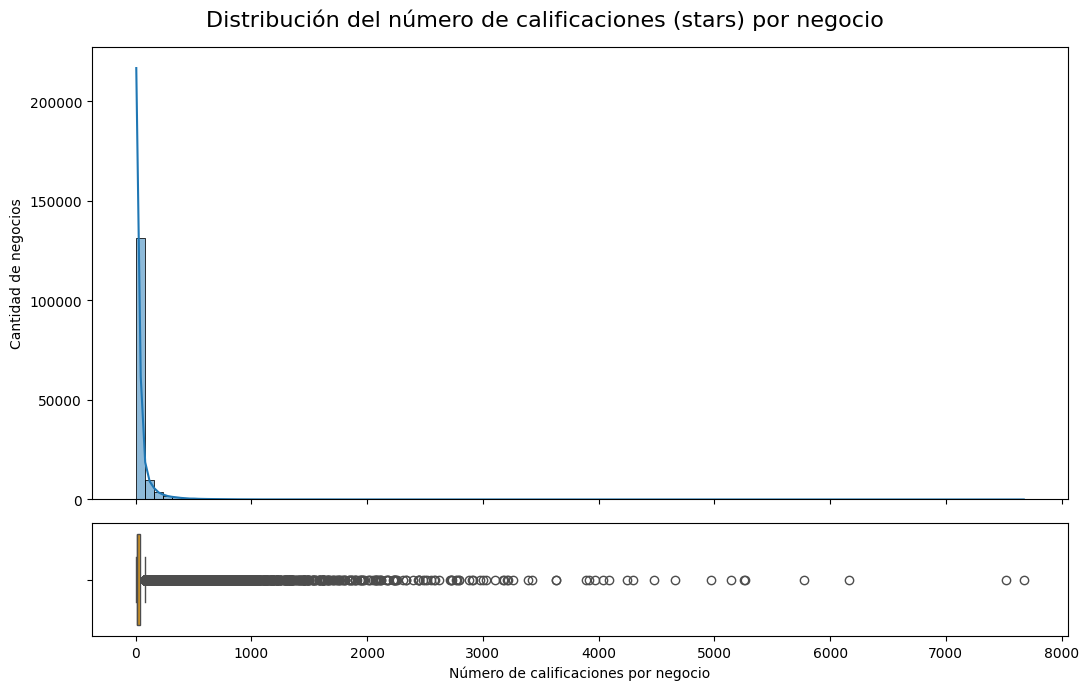

Distribución del número de calificaciones (stars) por negocio


,count
count,150346.000
mean,46.495
std,124.519
min,5.000
10%,6.000
20%,7.000
25%,8.000
30%,9.000
40%,11.000
50%,15.000


In [32]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=items_stats,
    x='count',
    bins=100,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de negocios')


# Boxplot
sns.boxplot(
    data=items_stats,
    x='count',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del número de calificaciones (stars) por negocio', fontsize=16)
plt.xlabel('Número de calificaciones por negocio')
plt.ylabel('')
plt.tight_layout()
plt.savefig(path_taller + '/Images/items_actividad.png')
plt.show()
print('Distribución del número de calificaciones (stars) por negocio')
items_stats['count'].describe(percentiles=[0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7,0.75, 0.8, 0.9])

### Distribución del promedio de calificaciones (rating) por película

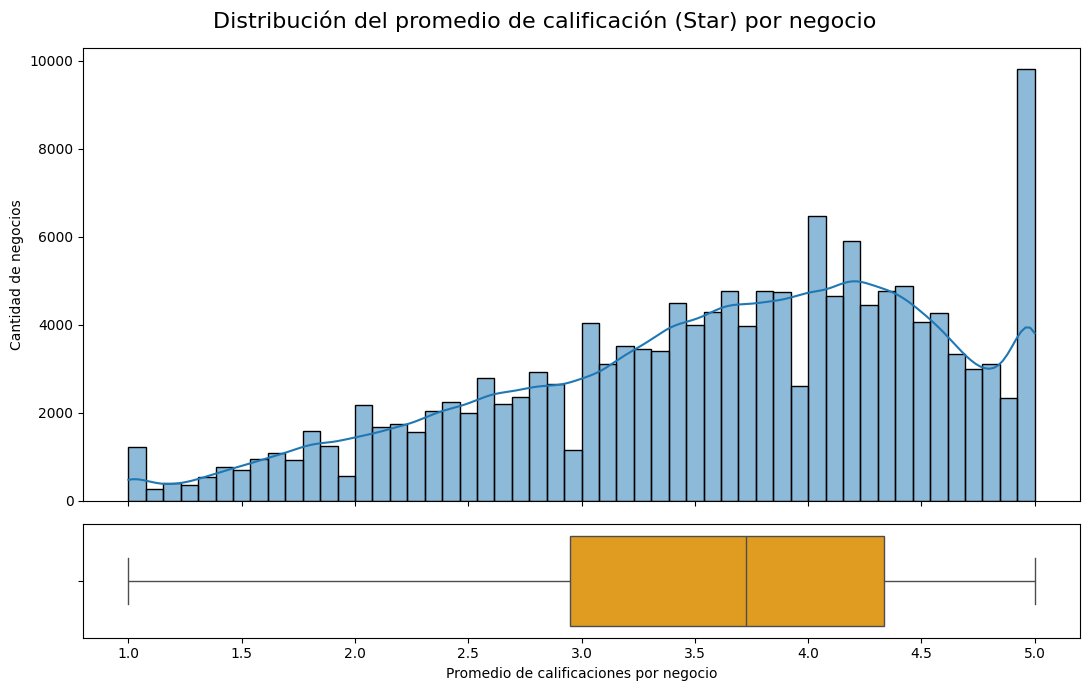

Distribución del promedio de calificación (Star) por negocio


,mean
count,150346.000
mean,3.588
std,0.962
min,1.000
25%,2.949
50%,3.727
75%,4.333
max,5.000


In [7]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11,7),
    sharex=True,
    gridspec_kw={'height_ratios':[4,1]}  # hist grande, box pequeño
)

# Histograma
sns.histplot(
    data=items_stats,
    x='mean',
    bins=52,
    kde=True,
    ax=ax1
)

ax1.set_xlabel("")
ax1.set_ylabel('Cantidad de negocios')


# Boxplot
sns.boxplot(
    data=items_stats,
    x='mean',
    ax=ax2,
    color='orange'
)

ax2.set_ylabel('')
ax2.set_xlabel('')

plt.suptitle('Distribución del promedio de calificación (Star) por negocio', fontsize=16)
plt.xlabel('Promedio de calificaciones por negocio')
plt.ylabel('')
plt.tight_layout()
plt.savefig(path_taller + '/Images/items_promedio.png')
plt.show()
print('Distribución del promedio de calificación (Star) por negocio')
items_stats['mean'].describe()

In [14]:
items_stats['std'].describe()

,std
count,150346.000
mean,1.282
std,0.527
min,0.000
25%,1.047
50%,1.388
75%,1.643
max,2.191


# **Muestreo Estratificado**

Con ayuda de `train_test_split` de scikit-learn creamos un muestreo estratificado de la actividad de los usuarios. El objetivo es quedarnos con el 10% de los usuarios (aproximadamente 13000) que representen la actividad general de los usuarios en el dataset.

In [ ]:
def sample_users(df_ratings, df_movies, test_size=0.9, random_state=SEED):

    user_stats = df_ratings.groupby('userId')['rating'].agg({'count','mean'}).sort_values(by='count', ascending=False)

    # PASO 1: Crear "grupos de actividad" para evitar errores de estratificación
    # Dividimos a los usuarios en 10 grupos (deciles) según su cantidad de calificaciones.
    # duplicates='drop' es por si hay muchos usuarios con el mismo número exacto de votos.
    user_stats['activity_group'] = pd.qcut(
        user_stats['count'],
        q=10,
        labels=False,
        duplicates='drop'
    )

    # PASO 2: Crear grupos de calificación promedio
    # para ayudar a mantener la distribución de ratings
    user_stats['rating_group'] = pd.qcut(
        user_stats['mean'],
        q=10,
        labels=False,
        duplicates='drop'
    )

    # PASO 3: Crear un grupo combinado de actividad y rating para una estratificación más robusta
    user_stats['activity_rating_group'] = user_stats['activity_group'].astype(str)
    user_stats['activity_rating_group'] += "_" + user_stats['rating_group'].astype(str)

    # PASO 4: Hacer el muestreo SOBRE LA TABLA DE USUARIOS (los 138k)
    users_sample, discarded_users = sklearn_train_test_split(
        user_stats,
        test_size= test_size, # Nos quedamos con el 10% de los usuarios (~13,800)
        stratify=user_stats['activity_rating_group'], # Estratificamos por su nivel de actividad
        random_state=SEED
    )
    # PASO 5: Filtrar la tabla gigante de calificaciones (los 20M)
    # Solo nos quedamos con las filas cuyo 'userId' esté dentro de nuestra muestra de usuarios
    ratings_sample = df_ratings[
        df_ratings['userId'].isin(users_sample.index)
    ]

    # Conservamos en `df_movies` solo los `movieId` presentes en `ratings_sample`.
    movies_sample = df_movies[df_movies['movieId'].isin(ratings_sample['movieId'].unique())]

    print("Número de usuarios:", ratings_sample['userId'].nunique())
    print("Número de películas:", ratings_sample['movieId'].nunique())
    print(f"Calificaciones totales de estos usuarios: {ratings_sample.shape[0]}")

    return ratings_sample, movies_sample

In [ ]:
ratings_sample, movies_sample = sample_users(df_ratings, df_movies)

Número de usuarios: 13849
Número de películas: 16688
Calificaciones totales de estos usuarios: 1973204


Revisamos la distribución de los ratings en el sample

In [ ]:
def review_sample_rating(ratings_sample, df_ratings):
    print('Distribución de calificaciones (rating) en la muestra vs original')
    distribucion_sample = (ratings_sample["rating"].value_counts().sort_index()/ ratings_sample.shape[0]).round(4)
    distribucion_original = (df_ratings["rating"].value_counts().sort_index()/ df_ratings.shape[0]).round(4)
    diferencia_distribucion = (distribucion_sample - distribucion_original).round(4)
    df_temp = pd.DataFrame({
        "rating": distribucion_sample.index,
        "distribucion_sample": distribucion_sample.values,
        "distribucion_original": distribucion_original.values,
        "diferencia_distribucion": diferencia_distribucion.values
    })
    display(df_temp)
review_sample_rating(ratings_sample, df_ratings)

Distribución de calificaciones (rating) en la muestra vs original


,rating,distribucion_sample,distribucion_original,diferencia_distribucion
0,0.5,0.0123,0.0120,0.0003
1,1.0,0.0334,0.0340,-0.0006
2,1.5,0.0134,0.0140,-0.0006
3,2.0,0.0704,0.0715,-0.0011
4,2.5,0.0431,0.0442,-0.0011
5,3.0,0.2140,0.2146,-0.0006
6,3.5,0.1112,0.1100,0.0012
7,4.0,0.2783,0.2781,0.0002
8,4.5,0.0778,0.0767,0.0011
9,5.0,0.1461,0.1449,0.0012


Revisamos la actividad de los usuarios en el sample

In [ ]:
def calculate_stats(df_ratings, user_stats = True):
    """ Estadísticas descriptivas usser/ítems"""
    group_by_col = 'userId' if user_stats else 'movieId'
    stats = df_ratings.groupby(group_by_col)['rating'].agg({'count','mean','var'}).reset_index()
    stats.rename(columns={'count':'num_ratings', 'mean':'average_rating', 'var':'rating_variance'}, inplace=True)
    return stats

def review_sample(df_ratings, ratings_sample, user_stats = True):

    original_stats = calculate_stats(ratings_sample, user_stats)
    sample_stats = calculate_stats(df_ratings, user_stats)

    title1 = 'Distribución de la actividad de usuarios' if user_stats else 'Distribución del número de calificaciones (rating) por película'
    df_num_ratings = pd.DataFrame({
        "num_ratings_sample": original_stats['num_ratings'],
        "num_ratings_original": sample_stats['num_ratings'],
    })
    print(title1)
    df1 = df_num_ratings.describe()
    df1["diferencia_num_ratings"] = (df1['num_ratings_sample'] - df1['num_ratings_original']).round(4)
    display(df1)

    title2 = 'Distribución del promedio de calificación (rating) de usuarios' if user_stats else 'Distribución del rating promedio por película'
    df_average_ratings = pd.DataFrame({
        "average_rating_sample": original_stats['average_rating'].round(4),
        "average_rating_original": sample_stats['average_rating'].round(4),
    })

    print(title2)
    df2 = df_average_ratings.describe()
    df2["diferencia_average_rating"] = (df2['average_rating_sample'] - df2['average_rating_original']).round(4)
    display(df2)

Revisamos la actividad de los usuarios en el sample

In [ ]:
review_sample(df_ratings, ratings_sample, user_stats=True)

Distribución de la actividad de usuarios


,num_ratings_sample,num_ratings_original,diferencia_num_ratings
count,13849.000000,138493.000000,-124644.0000
mean,142.479890,144.413530,-1.9336
std,214.451685,230.267257,-15.8156
min,20.000000,20.000000,0.0000
25%,35.000000,35.000000,0.0000
50%,68.000000,68.000000,0.0000
75%,155.000000,155.000000,0.0000
max,3291.000000,9254.000000,-5963.0000


Distribución del promedio de calificación (rating) de usuarios


,average_rating_sample,average_rating_original,diferencia_average_rating
count,13849.000000,138493.000000,-124644.0000
mean,3.627396,3.627209,0.0002
std,0.441791,0.443030,-0.0012
min,0.500000,0.500000,0.0000
25%,3.369300,3.369500,-0.0002
50%,3.653800,3.653800,0.0000
75%,3.925000,3.923100,0.0019
max,5.000000,5.000000,0.0000


Revisamos las estadisticas de los items en el sample

In [ ]:
review_sample(df_ratings, ratings_sample, user_stats=False)

Distribución del número de calificaciones (rating) por película


,num_ratings_sample,num_ratings_original,diferencia_num_ratings
count,16688.000000,26744.000000,-10056.0000
mean,118.240892,747.841123,-629.6002
std,382.334475,3085.818268,-2703.4838
min,1.000000,1.000000,0.0000
25%,2.000000,3.000000,-1.0000
50%,10.000000,18.000000,-8.0000
75%,57.000000,205.000000,-148.0000
max,6688.000000,67310.000000,-60622.0000


Distribución del rating promedio por película


,average_rating_sample,average_rating_original,diferencia_average_rating
count,16688.000000,26744.000000,-10056.0000
mean,3.253938,3.133200,0.1207
std,0.711400,0.664084,0.0473
min,0.500000,0.500000,0.0000
25%,2.913975,2.800000,0.1140
50%,3.363600,3.235300,0.1283
75%,3.737550,3.565200,0.1723
max,5.000000,5.000000,0.0000


Guardamos los archivos para entrenamiento

In [ ]:
ratings_sample.to_csv('../data/sample/rating.csv', index=False)
ratings_sample

,userId,movieId,rating,timestamp
1464,12,1,4.0,1997-03-22 20:48:38
1465,12,3,3.0,1997-03-22 20:49:34
1466,12,5,2.0,1997-03-22 20:49:34
1467,12,6,3.0,1997-03-22 20:49:34
1468,12,7,3.0,1997-03-22 20:49:34
...,...,...,...,...
19995088,138454,4351,1.0,2001-06-21 22:05:09
19995089,138454,4356,4.0,2001-06-21 22:04:51
19995090,138454,4357,3.0,2001-06-21 21:58:34
19995091,138454,4359,3.0,2001-06-21 21:57:47


In [ ]:
movies_sample.to_csv('../data/sample/movie.csv', index=False)
movies_sample

,movieId,title,year,average_rating,score_bayesiano,Adventure,Sci-Fi,Musical,Drama,Romance,...,Film-Noir,Children,War,Comedy,Horror,Crime,Animation,Fantasy,Documentary,Action
0,1,Toy Story (1995),1995,3.921240,3.901064,1,0,0,0,0,...,0,1,0,1,0,0,1,1,0,0
1,2,Jumanji (1995),1995,3.211977,3.207609,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2,3,Grumpier Old Men (1995),1995,3.151040,3.149381,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,4,Waiting to Exhale (1995),1995,2.861393,2.948770,0,0,0,1,1,...,0,0,0,1,0,0,0,0,0,0
4,5,Father of the Bride Part II (1995),1995,3.064592,3.071244,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26649,130976,Legend No. 17 (2013),2013,2.750000,3.132614,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
26650,130978,Love and Pigeons (1985),1985,4.000000,3.134526,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
26681,131080,Cinderella III: A Twist in Time (2007),2007,2.750000,3.132614,0,0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
26732,131237,What Men Talk About (2010),2010,3.000000,3.133098,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


# **Lista de recomendación no personalizada**

Se va a generar una lista no personalizada incorporando, además del promedio, el número de calificaciones de cada ítem. En particular, métodos basados en el límite inferior de un intervalo de confianza (por ejemplo, el puntaje de Wilson) ajustan el ranking penalizando ítems con pocas evaluaciones, cuyo promedio es estadísticamente menos confiable. De esta forma, la lista prioriza películas con valoraciones altas respaldadas por suficiente evidencia, reduciendo el sesgo hacia ítems con promedios altos pero con muy pocos ratings.

In [ ]:
def generar_lista_de_recomendacion_no_personalizada(df_ratings: pd.DataFrame, df_movies: pd.DataFrame, top_n: int):


    # 7. Ordenar de mayor a menor según el nuevo score
    top_movies = df_movies.sort_values('score_bayesiano', ascending=False)

    # Ver el Top 10 definitivo
    print(f"Top {top_n} items (movies) con mejor calificación promedio:")
    recommendations = top_movies.head(top_n)
    display(recommendations)
    return recommendations


In [ ]:
recomendations = generar_lista_de_recomendacion_no_personalizada(ratings_sample, movies_sample, top_n=10)

Top 10 items (movies) con mejor calificación promedio:


,movieId,title,year,average_rating,score_bayesiano,Adventure,Sci-Fi,Musical,Drama,Romance,...,Film-Noir,Children,War,Comedy,Horror,Crime,Animation,Fantasy,Documentary,Action
315,318,"Shawshank Redemption, The (1994)",1994,4.446990,4.420466,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
843,858,"Godfather, The (1972)",1972,4.364732,4.327039,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
49,50,"Usual Suspects, The (1995)",1995,4.334372,4.301909,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
523,527,Schindler's List (1993),1993,4.310175,4.280253,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1195,1221,"Godfather: Part II, The (1974)",1974,4.275641,4.223672,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1169,1193,One Flew Over the Cuckoo's Nest (1975),1975,4.248079,4.201478,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
895,912,Casablanca (1942),1942,4.258327,4.201063,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2873,2959,Fight Club (1999),1999,4.227123,4.192632,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,1
887,904,Rear Window (1954),1954,4.271334,4.192097,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
737,750,Dr. Strangelove or: How I Learned to Stop Worr...,1964,4.247287,4.187975,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
